<a href="https://colab.research.google.com/github/victorealeal/mod-1---regress-o/blob/main/Profissao_Cientista_de_Dados_M14_Pratique_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


# Nova seção

Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [4]:
df.dtypes

,0
customerID,object
Genero,object
Idoso,int64
Casado,object
Dependents,object
Tempo_como_Cliente,int64
PhoneService,object
Servico_Internet,object
Servico_Seguranca,object
Suporte_Tecnico,object


# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [8]:
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100

,0
customerID,0.00
Genero,0.48
Idoso,0.00
Casado,0.00
Dependents,0.00
Tempo_como_Cliente,0.00
PhoneService,59.28
Servico_Internet,0.00
Servico_Seguranca,0.00
Suporte_Tecnico,0.00


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [33]:
df.dropna(subset=['Genero','Churn'], inplace=True)
df[['Genero','Churn']].isnull().sum()
#Como a coluna Genero e Churm possuem apenas 0,48% e 0,20% respectivamente de dados faltantes, a exclusão das linhas não representa uma perda significativa da base de dados.

,0
Genero,0
Churn,0


C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

Média: 64.7914534883721
Mediana: 70.55


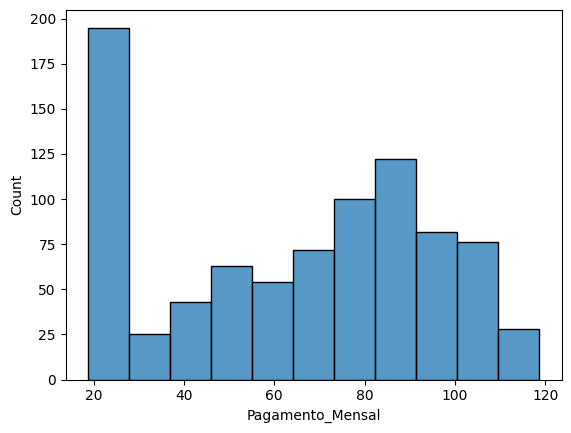

In [46]:
print("Média:", df['Pagamento_Mensal'].mean())
print("Mediana:", df['Pagamento_Mensal'].median())

sns.histplot(data=df, x='Pagamento_Mensal')
plt.show()


In [48]:
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(
    df['Pagamento_Mensal'].median()
)
df['Pagamento_Mensal'].isnull().sum()

np.int64(0)

A coluna Pagamento_Mensal possui 13% de dados faltantes. Após analisar a distribuição dos dados, verificou-se que a média (64,79) e a mediana (70,55) apresentam diferença. Como a distribuição dos dados apresenta assimetria, optou-se pela utilização da mediana para substituir os valores faltantes, pois ela é menos sensível a valores extremos e representa melhor a tendência central dos dados.

In [42]:
df['PhoneService'].value_counts()

,count
PhoneService,
Yes,920
No,86


variável PhoneService apresentou 59,28% de dados faltantes, representando mais da metade dos registros. Apesar de a categoria Yes ser a moda, a substituição desses valores poderia gerar uma distorção significativa na distribuição da variável. Dessa forma, optou-se pela exclusão da coluna.

In [54]:

df.isnull().sum()

,0
customerID,0
Genero,0
Idoso,0
Casado,0
Dependents,0
Tempo_como_Cliente,0
Servico_Internet,0
Servico_Seguranca,0
Suporte_Tecnico,0
StreamingTV,0


# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [62]:
for coluna in df.select_dtypes(include='object').columns:
    print(f'\n{coluna}:')
    print(df[coluna].value_counts())

df['Genero'] = df['Genero'].replace({
    'M': 'Male',
    'f': 'Female',
    'F': 'Female'
})

df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL'
})



customerID:
customerID
6061-GWWAV    1
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
             ..
3841-NFECX    1
8773-HHUOZ    1
5248-YGIJN    1
8665-UTDHZ    1
6467-CHFZW    1
Name: count, Length: 1006, dtype: int64

Genero:
Genero
Male      510
Female    496
Name: count, dtype: int64

Casado:
Casado
Yes    507
No     499
Name: count, dtype: int64

Dependents:
Dependents
No     664
Yes    342
Name: count, dtype: int64

Servico_Internet:
Servico_Internet
Fiber optic    431
DSL            357
No             218
Name: count, dtype: int64

Servico_Seguranca:
Servico_Seguranca
No                     494
Yes                    294
No internet service    218
Name: count, dtype: int64

Suporte_Tecnico:
Suporte_Tecnico
No                     513
Yes                    275
No internet service    218
Name: count, dtype: int64

StreamingTV:
StreamingTV
No                     411
Yes                    377
No internet service    218
Name: count, dtype: int64

Tipo_Contrato:


# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [63]:
df.rename(columns={
    'customerID': 'ID_Cliente',
    'Genero': 'Genero',
    'Idoso': 'Idoso',
    'Casado': 'Casado',
    'Dependents': 'Dependentes',
    'Tempo_como_Cliente': 'Tempo_como_Cliente',
    'PhoneService': 'Servico_Telefonico',
    'Servico_Internet': 'Servico_Internet',
    'Servico_Seguranca': 'Servico_Seguranca',
    'Suporte_Tecnico': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'Tipo_Contrato': 'Tipo_Contrato',
    'PaymentMethod': 'Metodo_Pagamento',
    'Pagamento_Mensal': 'Pagamento_Mensal',
    'Total_Pago': 'Total_Pago',
    'Churn': 'Churn'
}, inplace=True)

df.columns

Index(['ID_Cliente', 'Genero', 'Idoso', 'Casado', 'Dependentes',
       'Tempo_como_Cliente', 'Servico_Internet', 'Servico_Seguranca',
       'Suporte_Tecnico', 'Streaming_TV', 'Tipo_Contrato', 'Metodo_Pagamento',
       'Pagamento_Mensal', 'Total_Pago', 'Churn'],
      dtype='object')